In [29]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [30]:
#load Data
df = pd.read_csv('Mall_Customers.csv')

df.head()

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=0)
y_kmeans = kmeans.fit_predict(X_scaled)

df['Cluster'] = y_kmeans
print(df.groupby('Cluster').agg({'Age': 'mean', 'Annual Income (k$)': 'mean', 'Spending Score (1-100)': 'mean'}))


               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        42.716049           55.296296               49.518519
1        32.692308           86.538462               82.128205
2        41.114286           88.200000               17.114286
3        45.217391           26.304348               20.913043
4        25.272727           25.727273               79.363636


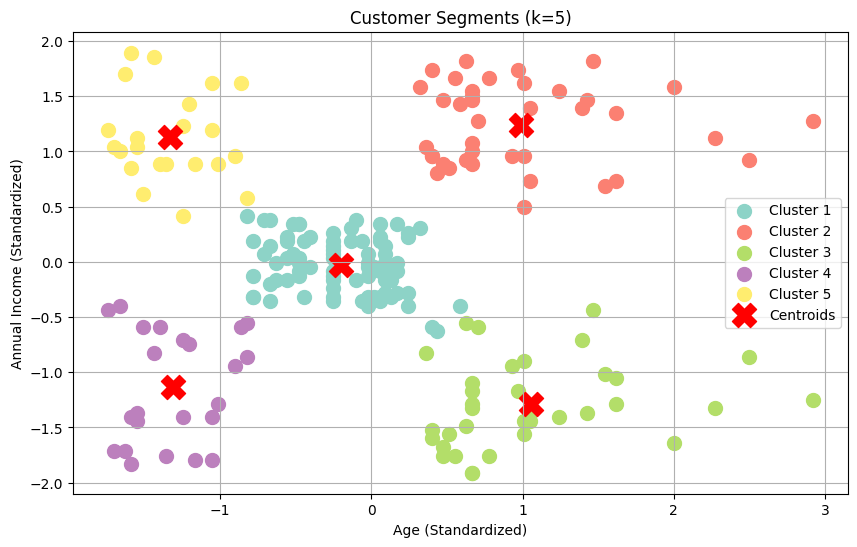

In [31]:
#Cluster visualization
# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

# Cluster visualization
colors = plt.cm.Set3(np.linspace(0, 1, optimal_k))
for i in range(optimal_k):
    ax.scatter(X_scaled[y_kmeans == i, 0], X_scaled[y_kmeans == i, 1], 
                s=100, c=[colors[i]], label=f'Cluster {i+1}')
ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            s=300, c='red', marker='X', label='Centroids')
ax.set_title(f'Customer Segments (k={optimal_k})')
ax.set_xlabel('Age (Standardized)')
ax.set_ylabel('Annual Income (Standardized)')
ax.legend()
ax.grid()